In [ ]:
./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --build --run

In [1]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/prefetch_buffer_eval.ini --parse

/home/bscuser/synched_mnt/VMem
Preprocessing configuration file...
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/prefetch_buffer_eval/BASELINE', './data/prefetch_buffer_eval']
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list
created directory ./data/prefetch_buffer_eval
BASELINE/
BASELINE/selected_qualcomm_srv_ap_0_BASELINE_run.out
BASELINE/selected_qualcomm_srv_ap_20_BASELINE_run.out
BASELINE/selected_qualcomm_srv_ap_40_BASELINE_run.out
BASELINE/selected_qualcomm_srv_ap_60_BASELINE_run.out
BASELINE/selected_qualcomm_srv_ap_80_BASELINE_run.out
BASELINE/srv100_ap_BASELINE_run.out
BASELINE/srv103_ap_BASELINE_run.out
BASELINE/srv111_ap_BASELINE_run.out
BASELINE/srv120_ap

/home/bscuser/synched_mnt/VMem
Preprocessing configuration file...
['BASELINE', 'sblgpf_gate-75_thld-1_tblsz-65536_accwindow-32_acc_threshold-0_degree-1_pfbuffer-L2C', 'childpf_gate-75_thld-1_tblsz-65536_pendingsz-65536_trainonhit-1_pfbuffer-L2C']
Plotting prefetch_buffer_eval for selected_qualcomm_srv_ap
['BASELINE', 'SBLG-PF', 'CHILD-PF']
        tag  IPC_IMPROVEMENT
0  CHILD-PF         0.034015
1   SBLG-PF         0.034015
SBLG-PF:0.5072855421920228
CHILD-PF:0.5072855421920228
  benchmarks       tag      mean
0       mean   SBLG-PF  0.507286
1       mean  CHILD-PF  0.507286
  benchmarks       tag      mean
0       mean   SBLG-PF  0.507286
1       mean  CHILD-PF  0.507286
./figures/prefetch_buffer_eval/prefetch_buffer_eval_ipc_selected_qualcomm_srv_ap.png
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
Plotting completed successfully
['BASELINE', 'sblgpf_gate-75_thld-1_tblsz-6

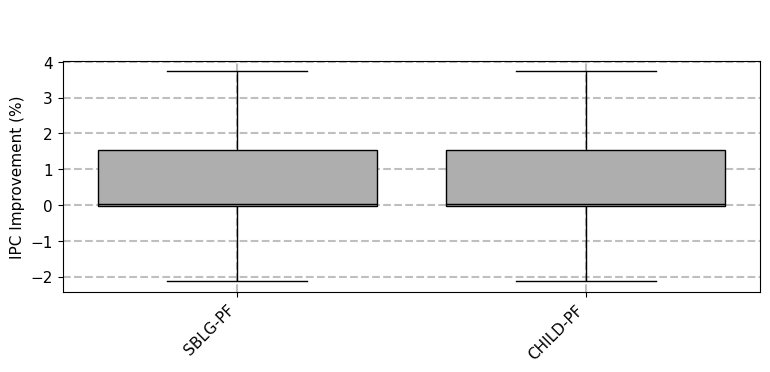

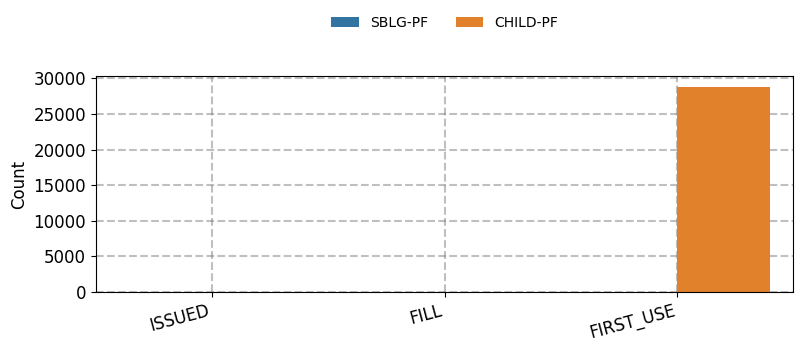

In [9]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/prefetch_buffer_eval.ini --plot

from IPython.display import Image, display
display(Image("./figures/prefetch_buffer_eval/prefetch_buffer_eval_ipc_selected_qualcomm_srv_ap.png", 
width=600, height=600))

display(Image("./figures/prefetch_buffer_eval/prefetch_buffer_eval_txvc_prefetch_funnel_selected_qualcomm_srv_ap.png", 
width=600, height=600))



### Child Stage/Coverage Analysis (Prefetch Buffer Eval)

> Adapted from txvc_prefetcher notebook for prefetch_buffer_eval outputs.

Auto-loaded 4800 rows from /home/bscuser/synched_mnt/VMem/stats/prefetch_buffer_eval/childpf_gate-75_thld-1_tblsz-65536_pendingsz-65536_trainonhit-1_pfbuffer-L2C/selected_qualcomm_srv_ap_childpf_gate-75_thld-1_tblsz-65536_pendingsz-65536_trainonhit-1_pfbuffer-L2C.csv


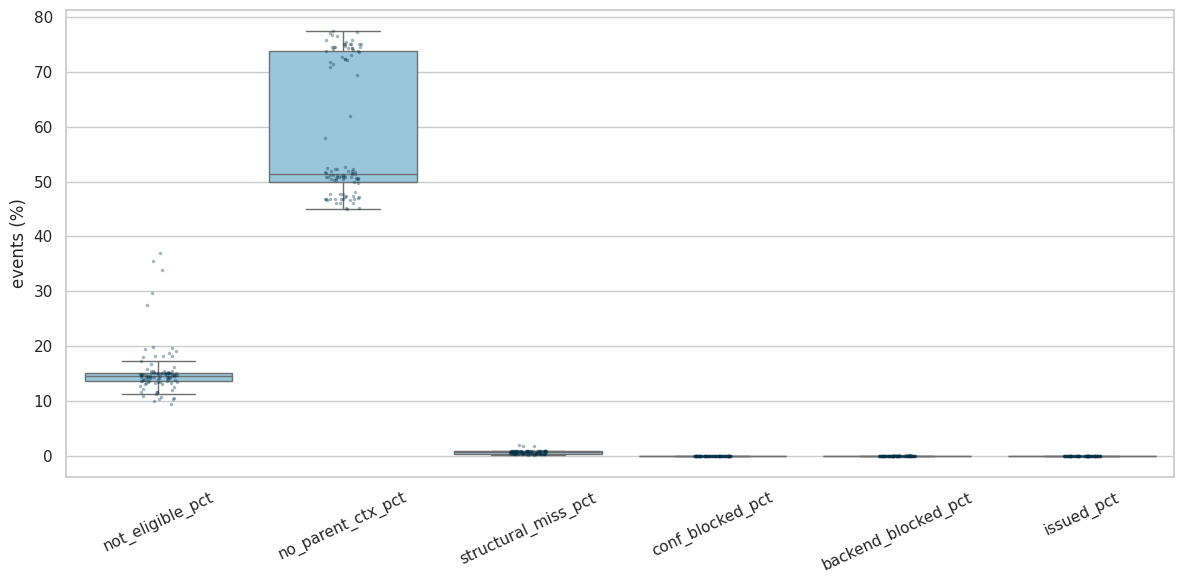

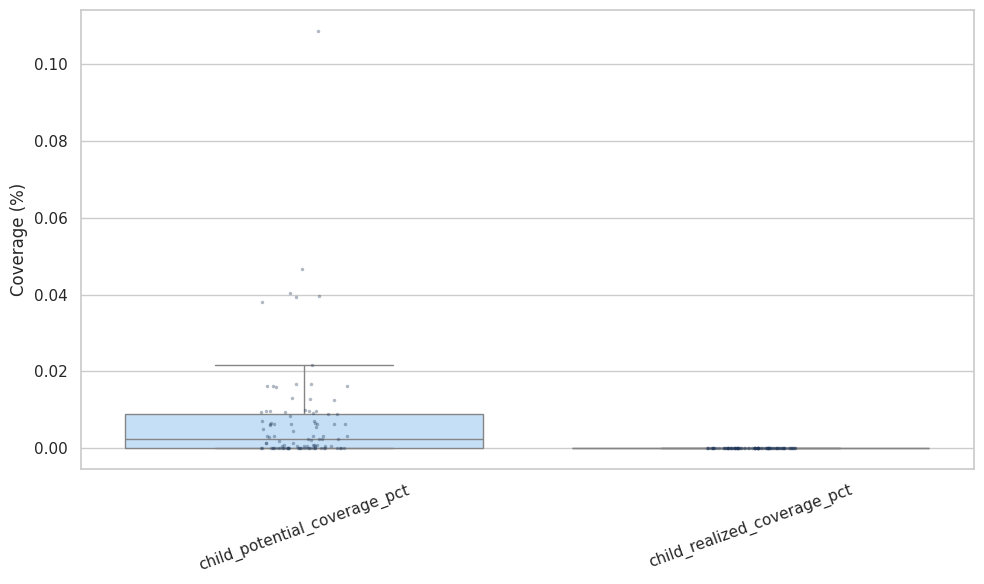

Saved PDF: /home/bscuser/synched_mnt/VMem/figures/prefetch_buffer_eval/prefetch_buffer_child_stage_share_boxplot.pdf
Saved PDF: /home/bscuser/synched_mnt/VMem/figures/prefetch_buffer_eval/prefetch_buffer_child_coverage_boxplot.pdf


,__bench,TXVC_CHILD_DROP_PRED_ISSUED,TXVC_CHILD_DROP_NO_PENDING_PARENT,child_not_eligible,child_structural_miss,TXVC_CHILD_DROP_PRED_CONF_BLOCKED,child_backend_blocked,child_potential_coverage_pct,child_realized_coverage_pct
1255,srv12_ap,0.0,83028.0,30783.0,823.0,0.0,0.0,0.000000,0.0
2594,srv628_ap,0.0,23265.0,4890.0,248.0,0.0,2.0,0.006343,0.0
1921,srv635_ap,0.0,23445.0,4659.0,258.0,0.0,4.0,0.012629,0.0
1847,srv323_ap,0.0,23024.0,4785.0,251.0,0.0,2.0,0.006270,0.0
1711,srv520_ap,0.0,23241.0,4655.0,266.0,0.0,3.0,0.009350,0.0
1364,srv406_ap,0.0,23472.0,4883.0,273.0,0.0,3.0,0.009293,0.0
1913,srv419_ap,0.0,23171.0,4871.0,238.0,0.0,1.0,0.003087,0.0
2100,srv65_ap,0.0,23447.0,4887.0,226.0,0.0,7.0,0.021607,0.0
2673,srv587_ap,0.0,23427.0,4775.0,271.0,0.0,2.0,0.006135,0.0
2478,srv538_ap,0.0,23499.0,4495.0,257.0,0.0,3.0,0.009043,0.0


In [10]:
# Boxplots across benchmarks for child-prefetch + prefetch-buffer runs
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Resolve workspace root whether the notebook runs from repo root or notebooks/.
base_dir = Path.cwd()
if not (base_dir / "stats").exists() and (base_dir.parent / "stats").exists():
    base_dir = base_dir.parent

# Output directory for exported figures
pdf_out_dir = base_dir / "figures" / "prefetch_buffer_eval"
pdf_out_dir.mkdir(parents=True, exist_ok=True)

required_raw = [
    "TXVC_CHILD_DROP_LEVEL0_SKIP",
    "TXVC_CHILD_DROP_LEAF_NO_PREDICT",
    "TXVC_CHILD_DROP_NO_PENDING_PARENT",
    "TXVC_CHILD_DROP_PENDING_OVERWRITE_COLLISION",
    "TXVC_CHILD_DROP_PRED_INVALID",
    "TXVC_CHILD_DROP_PRED_TAG_MISMATCH",
    "TXVC_CHILD_DROP_PRED_CONF_BLOCKED",
    "TXVC_CHILD_DROP_PRED_ISSUED",
    "TXVC_CHILD_DROP_ISSUE_MSHR_BLOCKED",
    "TXVC_CHILD_DROP_ISSUE_ENQUEUE_FAILED",
]

# Use existing dataframe if it already contains child-drop counters; otherwise auto-load
# from parsed prefetch_buffer_eval outputs.
if (
    "d" in globals()
    and isinstance(d, pd.DataFrame)
    and not d.empty
    and all(c in d.columns for c in required_raw)
):
    box_df = d.copy()
else:
    preferred = sorted(
        (base_dir / "stats" / "prefetch_buffer_eval").glob(
            "**/*childpf*pfbuffer-L2C*/selected_*.csv"
        )
    )
    fallback = sorted((base_dir / "stats" / "prefetch_buffer_eval").glob("**/*childpf*/*.csv"))
    candidates = preferred + fallback

    box_df = None
    loaded_path = None
    for p in candidates:
        if not p.exists():
            continue
        try:
            tmp = pd.read_csv(p)
        except Exception:
            continue
        if all(c in tmp.columns for c in required_raw):
            box_df = tmp
            loaded_path = p
            break

    if box_df is None:
        raise RuntimeError(
            "Could not find a parsed CSV with TXVC child drop columns under stats/prefetch_buffer_eval. "
            "Run --parse first, or provide dataframe d in a previous cell."
        )

    print(f"Auto-loaded {len(box_df)} rows from {loaded_path}")

if "__bench" not in box_df.columns:
    if "benchmarks" in box_df.columns:
        box_df["__bench"] = box_df["benchmarks"].astype(str).str.strip()
    else:
        box_df["__bench"] = "unknown"

for c in required_raw:
    box_df[c] = pd.to_numeric(box_df[c], errors="coerce").fillna(0)

# Keep one representative row per benchmark to avoid duplicate rows from merged outputs.
box_df["_child_total"] = box_df[required_raw].sum(axis=1)
box_df = box_df.sort_values("_child_total", ascending=False).drop_duplicates("__bench").copy()

# Build composite counters
box_df["child_not_eligible"] = (
    box_df["TXVC_CHILD_DROP_LEVEL0_SKIP"] + box_df["TXVC_CHILD_DROP_LEAF_NO_PREDICT"]
)
box_df["child_structural_miss"] = (
    box_df["TXVC_CHILD_DROP_PRED_INVALID"] + box_df["TXVC_CHILD_DROP_PRED_TAG_MISMATCH"]
)
box_df["child_backend_blocked"] = (
    box_df["TXVC_CHILD_DROP_ISSUE_MSHR_BLOCKED"] + box_df["TXVC_CHILD_DROP_ISSUE_ENQUEUE_FAILED"]
)

# Stage components for distribution plots
stage_budget = (
    box_df["child_not_eligible"]
    + box_df["TXVC_CHILD_DROP_NO_PENDING_PARENT"]
    + box_df["TXVC_CHILD_DROP_PENDING_OVERWRITE_COLLISION"]
    + box_df["child_structural_miss"]
    + box_df["TXVC_CHILD_DROP_PRED_CONF_BLOCKED"]
    + box_df["TXVC_CHILD_DROP_PRED_ISSUED"]
    + box_df["child_backend_blocked"]
).replace(0, np.nan)

box_df["not_eligible_pct"] = 100.0 * box_df["child_not_eligible"] / stage_budget
box_df["no_parent_ctx_pct"] = 100.0 * box_df["TXVC_CHILD_DROP_NO_PENDING_PARENT"] / stage_budget
box_df["structural_miss_pct"] = 100.0 * box_df["child_structural_miss"] / stage_budget
box_df["conf_blocked_pct"] = 100.0 * box_df["TXVC_CHILD_DROP_PRED_CONF_BLOCKED"] / stage_budget
box_df["backend_blocked_pct"] = 100.0 * box_df["child_backend_blocked"] / stage_budget
box_df["issued_pct"] = 100.0 * box_df["TXVC_CHILD_DROP_PRED_ISSUED"] / stage_budget

box_df["child_potential_coverage_pct"] = 100.0 * (
    box_df["TXVC_CHILD_DROP_PRED_ISSUED"] + box_df["child_backend_blocked"]
) / stage_budget
box_df["child_realized_coverage_pct"] = 100.0 * box_df["TXVC_CHILD_DROP_PRED_ISSUED"] / stage_budget

# 1) Distribution of stage shares across benchmarks
stage_metrics = [
    "not_eligible_pct",
    "no_parent_ctx_pct",
    "structural_miss_pct",
    "conf_blocked_pct",
    "backend_blocked_pct",
    "issued_pct",
]
stage_long = box_df.melt(value_vars=stage_metrics, var_name="metric", value_name="pct")

plt.figure(figsize=(12, 6))
sns.boxplot(data=stage_long, x="metric", y="pct", color="#8ecae6", showfliers=False)
sns.stripplot(data=stage_long, x="metric", y="pct", color="#023047", size=2.5, alpha=0.35)
plt.title("")
plt.xlabel("")
plt.ylabel("events (%)")
plt.xticks(rotation=25)
plt.tight_layout()
stage_pdf = pdf_out_dir / "prefetch_buffer_child_stage_share_boxplot.pdf"
plt.savefig(stage_pdf, format="pdf", bbox_inches="tight")
plt.show()

# 2) Coverage distributions across benchmarks
cov_metrics = [
    "child_potential_coverage_pct",
    "child_realized_coverage_pct",
]
cov_long = box_df.melt(value_vars=cov_metrics, var_name="metric", value_name="pct")

plt.figure(figsize=(10, 6))
sns.boxplot(data=cov_long, x="metric", y="pct", color="#bde0fe", showfliers=False)
sns.stripplot(data=cov_long, x="metric", y="pct", color="#1d3557", size=2.5, alpha=0.35)
plt.title("")
plt.xlabel("")
plt.ylabel("Coverage (%)")
plt.xticks(rotation=20)
plt.tight_layout()
coverage_pdf = pdf_out_dir / "prefetch_buffer_child_coverage_boxplot.pdf"
plt.savefig(coverage_pdf, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved PDF: {stage_pdf}")
print(f"Saved PDF: {coverage_pdf}")

# Optional: low-realized-coverage outliers
outlier_view = box_df[[
    "__bench",
    "TXVC_CHILD_DROP_PRED_ISSUED",
    "TXVC_CHILD_DROP_NO_PENDING_PARENT",
    "child_not_eligible",
    "child_structural_miss",
    "TXVC_CHILD_DROP_PRED_CONF_BLOCKED",
    "child_backend_blocked",
    "child_potential_coverage_pct",
    "child_realized_coverage_pct",
]].copy()

outlier_view.sort_values("child_realized_coverage_pct", ascending=True).head(15)

In [14]:
# Prefetch usefulness: issued vs useful (buffer eval)

import re

if "box_df" not in globals() or box_df is None or box_df.empty:
    raise RuntimeError("Run the previous analysis cell first to populate box_df.")

# Find candidate columns for issued/useful counters in parsed CSV output.
issued_pat = re.compile(r"(pred_issued|pf_issued|prefetch.*issued|issued.*prefetch)", re.IGNORECASE)
useful_pat = re.compile(r"(pf_useful|prefetch.*useful|useful.*prefetch|first_use|hit_prefetch)", re.IGNORECASE)

issued_cols = [c for c in box_df.columns if issued_pat.search(str(c))]
useful_cols = [c for c in box_df.columns if useful_pat.search(str(c))]

# Prefer child-specific counters when available.
preferred_issued = [
    "TXVC_CHILD_DROP_PRED_ISSUED",
    "TXVC_CHILD_PRED_ISSUED",
    "CHILD_PRED_ISSUED",
]
preferred_useful = [
    "TXVC_CHILD_FIRST_USE",
    "TXVC_CHILD_FIRST_USE_SUM",
    "TXVC_CHILD_USEFUL",
    "TXVC_PF_LT_FIRST_USE",
    "TXVC_PF_USEFUL",
    "L2C_PF_USEFUL",
]

issued_col = next((c for c in preferred_issued if c in box_df.columns), issued_cols[0] if issued_cols else None)
useful_col = next((c for c in preferred_useful if c in box_df.columns), useful_cols[0] if useful_cols else None)

if issued_col is None or useful_col is None:
    print("Could not auto-detect both issued and useful columns from this parsed CSV.")
    print("Issued candidates:", issued_cols)
    print("Useful candidates:", useful_cols)

    # Show likely fallback columns to help manual mapping.
    pref_cols = [c for c in box_df.columns if re.search(r"child|prefetch|pf|use|hit", str(c), re.IGNORECASE)]
    print("\nRelated columns (first 80):")
    for c in pref_cols[:80]:
        print(" -", c)

    print("\nTip: if your parse output does not include a useful counter, add/export one (e.g., pf_useful or first_use) in the stats parser.")
else:
    tmp = box_df.copy()
    tmp[issued_col] = pd.to_numeric(tmp[issued_col], errors="coerce").fillna(0)
    tmp[useful_col] = pd.to_numeric(tmp[useful_col], errors="coerce").fillna(0)

    # If the parsed file mixes multiple simulations, try to keep only child-prefetch rows.
    string_cols = [c for c in tmp.columns if str(tmp[c].dtype) in ("object", "string")]
    child_mask = pd.Series(False, index=tmp.index)
    for c in string_cols:
        try:
            child_mask = child_mask | tmp[c].astype(str).str.contains(r"childpf|tx_child|pf-child|child", case=False, regex=True, na=False)
        except Exception:
            pass

    if child_mask.any():
        child_tmp = tmp[child_mask].copy()
        if child_tmp[issued_col].sum() > 0 or tmp[issued_col].sum() == 0:
            tmp = child_tmp
            print(f"Filtered to child-related rows: {len(tmp)}")

    # Ensure one representative row per benchmark if available.
    if "__bench" in tmp.columns:
        tmp = tmp.sort_values(issued_col, ascending=False).drop_duplicates("__bench").copy()

    total_issued = float(tmp[issued_col].sum())
    total_useful = float(tmp[useful_col].sum())
    usefulness_pct = (100.0 * total_useful / total_issued) if total_issued > 0 else np.nan

    print(f"Issued column: {issued_col}")
    print(f"Useful column: {useful_col}")
    print(f"Total issued: {total_issued:,.0f}")
    print(f"Total useful: {total_useful:,.0f}")
    print(f"Usefulness (% useful/issued): {usefulness_pct:.2f}%")

    if total_issued == 0:
        print("\nNote: issued=0 for the selected rows. This usually means either:")
        print(" - this dataset does not include child-prefetch simulation rows, or")
        print(" - child prefetching did not issue in this run.")

    # Per-benchmark view (top/bottom by usefulness)
    if "__bench" in tmp.columns:
        bench_view = tmp[["__bench", issued_col, useful_col]].copy()
        bench_view = bench_view.rename(columns={issued_col: "issued", useful_col: "useful"})
        bench_view["usefulness_pct"] = 100.0 * bench_view["useful"] / bench_view["issued"].replace(0, np.nan)

        print("\nLowest usefulness benchmarks:")
        display(bench_view.sort_values("usefulness_pct", ascending=True).head(10))

        print("Highest usefulness benchmarks:")
        display(bench_view.sort_values("usefulness_pct", ascending=False).head(10))

Issued column: TXVC_CHILD_DROP_PRED_ISSUED
Useful column: TXVC_PF_LT_FIRST_USE
Total issued: 0
Total useful: 0
Usefulness (% useful/issued): nan%

Note: issued=0 for the selected rows. This usually means either:
 - this dataset does not include child-prefetch simulation rows, or
 - child prefetching did not issue in this run.

Lowest usefulness benchmarks:


,__bench,issued,useful,usefulness_pct
1255,srv12_ap,0.0,0.0,NaN
3078,srv585_ap,0.0,0.0,NaN
2977,srv141_ap,0.0,0.0,NaN
2594,srv628_ap,0.0,0.0,NaN
1921,srv635_ap,0.0,0.0,NaN
1847,srv323_ap,0.0,0.0,NaN
1711,srv520_ap,0.0,0.0,NaN
1364,srv406_ap,0.0,0.0,NaN
1913,srv419_ap,0.0,0.0,NaN
2100,srv65_ap,0.0,0.0,NaN


Highest usefulness benchmarks:


,__bench,issued,useful,usefulness_pct
1255,srv12_ap,0.0,0.0,NaN
3078,srv585_ap,0.0,0.0,NaN
2977,srv141_ap,0.0,0.0,NaN
2594,srv628_ap,0.0,0.0,NaN
1921,srv635_ap,0.0,0.0,NaN
1847,srv323_ap,0.0,0.0,NaN
1711,srv520_ap,0.0,0.0,NaN
1364,srv406_ap,0.0,0.0,NaN
1913,srv419_ap,0.0,0.0,NaN
2100,srv65_ap,0.0,0.0,NaN
